In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Create a dataframe titled movie_ratings that contains the ratings (G, PG, TV-G, etc) and how many of those movies exist in the dataframe

In [3]:
disney = pd.read_csv('./disney_plus.csv')

In [4]:
movie_ratings = disney.loc[disney.type == 'Movie']
new_movie_ratings = movie_ratings['rating'].value_counts().reset_index()
new_movie_ratings.head()

,rating,count
0,G,235
1,PG,226
2,TV-G,224
3,TV-PG,165
4,PG-13,60


2. Using the movie_ratings dataframe, create a bar chart that displays the count of the top 5 movie ratings.

💡 Hint: Use .plot.bar() with x='rating' and y='count'. Don't forget to add a title and axis label!

Text(0, 0.5, 'Count')

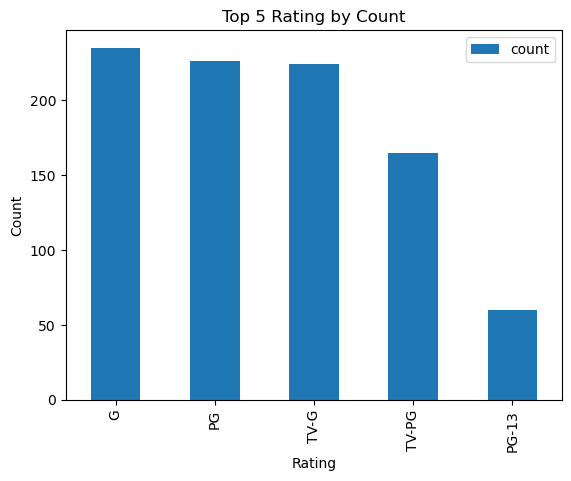

In [6]:
new_movie_ratings.head(5).plot.bar(x='rating', y='count')
plt.title('Top 5 Rating by Count')
plt.xlabel('Rating')
plt.ylabel('Count')

3. Using movies_df, subset the data to create a new dataframe named year_duration that contains only two columns:

release_year
duration

In [12]:
year_duration = movie_ratings[['release_year', 'duration']]
year_duration.tail()

,release_year,duration
1359,2001,73 min
1361,1978,104 min
1362,1986,75 min
1363,1963,80 min
1364,1965,132 min


4. Using your year_duration dataframe, filter for movies released between 1975 and 1984 (inclusive) and find the:

Minimum duration
Maximum duration
Average duration

In [20]:
durations = year_duration.loc[(year_duration.release_year >= 1975) & (year_duration.release_year <= 1984)]

In [32]:
durations['duration'] = year_duration.duration.str[:-4].astype('int')

C:\Users\geish\AppData\Local\Temp\ipykernel_49812\3011619860.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  durations['duration'] = year_duration.duration.str[:-4].astype('int')


In [40]:
durations.describe()

,release_year,duration
count,35.000000,35.000000
mean,1979.000000,85.914286
std,2.849148,30.415139
min,1975.000000,2.000000
25%,1977.000000,81.500000
50%,1979.000000,94.000000
75%,1981.000000,100.000000
max,1984.000000,135.000000


5. Using the year_duration dataframe, create a scatterplot that shows movie durations over the years. Add a descriptive title to your chart.

After creating your plot, answer the following in a comment or markdown cell:

Do you notice any correlation between release year and movie duration?



In [57]:
year_duration['duration'] = year_duration.duration.str[:-4].astype('int')

C:\Users\geish\AppData\Local\Temp\ipykernel_49812\1752339534.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  year_duration['duration'] = year_duration.duration.str[:-4].astype('int')


Text(0.5, 1.0, 'Release Year vs Duration')

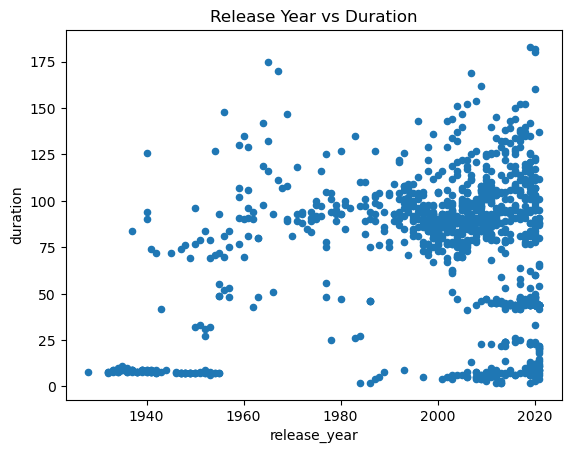

In [61]:
year_duration.plot.scatter(x='release_year', y='duration')
plt.title('Release Year vs Duration')

6. Find the actual correlation value between release_year and duration.

💡 Hint: Use .corr() on the year_duration dataframe.

Answer the following in a comment or markdown cell:

Based on the correlation value, is there a meaningful correlation between release year and duration?



In [67]:
year_duration.corr()

,release_year,duration
release_year,1.000000,0.241268
duration,0.241268,1.000000


In [69]:
# 1 indicates perfect agreement between the rankings of the two variables.
# -1 indicates perfect disagreement.
# 0 suggests no association between the rankings.

7. Using movies_df, find which year had the most G-rated movie releases.

🎯 Challenge: Can you accomplish this in a single line of code?

In [73]:
movie_ratings.loc[movie_ratings.rating == 'G'].release_year.value_counts().reset_index()

,release_year,count
0,2003,12
1,2011,10
2,2006,10
3,2008,10
4,2005,10
...,...,...
69,1987,1
70,1942,1
71,1951,1
72,1994,1


8. Find which year had the most total movie releases.
- Create a new dataframe containing only movies from that year.
- Convert the duration column to integers.
- Use the IQR method to determine the upper and lower cutoffs for outliers.


In [77]:
movie_ratings.release_year.value_counts().reset_index()

,release_year,count
0,2020,72
1,2019,60
2,2021,42
3,2017,32
4,2018,32
...,...,...
85,1944,1
86,1970,1
87,1945,1
88,1982,1


In [81]:
movies_2020 = movie_ratings.loc[movie_ratings.release_year == 2020]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
551,s552,Movie,Timmy Failure: Mistakes Were Made,Tom McCarthy,"Winslow Fegley, Ophelia Lovibond, Craig Robins...",United States,"February 7, 2020",2020,PG,103 min,"Buddy, Comedy, Drama",“Timmy Failure” follows the hilarious exploits...
556,s557,Movie,Lamp Life,Valerie LaPointe,"Annie Potts, Jim Hanks, Ally Maki, Emily Davis",United States,"January 31, 2020",2020,TV-G,11 min,"Animation, Comedy, Family",Lamp Life answers the question of what happene...
567,s568,Movie,Forky Asks a Question: What is Reading?,Bob Peterson,"Tony Hale, Addison Andrews, Mila Crespo, Imani...",United States,"January 10, 2020",2020,TV-G,7 min,"Animation, Comedy, Family",The energetic Peas-n-a-Pod siblings teach Fork...
568,s569,Movie,Loop,Erica Milsom,"Madison Bandy, Christiano Delgado, Louis Gonza...",United States,"January 10, 2020",2020,PG,12 min,"Animation, Family","Adrift on a lake, two kids with different ways..."
571,s572,Movie,Forky Asks a Question: What is Cheese?,Bob Peterson,"Tony Hale, Jeff Garlin, Bob Peterson",United States,"January 3, 2020",2020,TV-G,6 min,"Animation, Comedy, Family","Buttercup, annoyed with all of Forky’s questio..."


In [90]:
movies_2020['duration'] = movies_2020.duration.str[:-4].astype('int')

C:\Users\geish\AppData\Local\Temp\ipykernel_49812\3140514753.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_2020['duration'] = movies_2020.duration.str[:-4].astype('int')


In [92]:
movies_2020.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
10,s11,Movie,Jade Eyed Leopard,NaN,Jeremy Irons,NaN,"September 17, 2021",2020,TV-PG,44,"Animals & Nature, Documentary","Jade Eyed Leopard follows a leopard, Toto, thr..."
65,s66,Movie,Shark vs. Surfer,Phil Stebbing,Billy Lloyd,NaN,"July 23, 2021",2020,TV-14,44,"Animals & Nature, Documentary",Shark vs. Surfer visits shark-infested surf sp...
66,s67,Movie,Shark vs. Whale,NaN,Ted Stewart,NaN,"July 23, 2021",2020,TV-PG,44,"Animals & Nature, Documentary",Marine biologist Ryan Johnson discovers rare b...
69,s70,Movie,What the Shark?,NaN,Robert Davi,NaN,"July 23, 2021",2020,TV-PG,44,"Animals & Nature, Documentary",What the Shark? dives deep into the environmen...
75,s76,Movie,Most Wanted Sharks,NaN,NaN,NaN,"July 16, 2021",2020,TV-PG,44,"Animals & Nature, Documentary","In Most Wanted Sharks, Jeremiah Sullivan dives..."


In [94]:
movies_2020.describe()

,release_year,duration
count,72.0,72.000000
mean,2020.0,67.013889
std,0.0,40.021295
min,2020.0,3.000000
25%,2020.0,44.000000
50%,2020.0,49.000000
75%,2020.0,95.000000
max,2020.0,182.000000


- Calculate what percentage of movies from that year had durations that were statistical outliers.
- 💡 Hint: Outlier cutoffs are defined as:

- Lower cutoff: Q1 − (1.5 × IQR)
- Upper cutoff: Q3 + (1.5 × IQR)

In [97]:
IQR = movies_2020.describe().loc['75%', 'duration'] -  movies_2020.describe().loc['25%', 'duration'] 
IQR

51.0

In [101]:
lower_cutoff = movies_2020.describe().loc['25%', 'duration'] - (1.5 * IQR)
lower_cutoff

-32.5

In [103]:
upper_cutoff = movies_2020.describe().loc['75%', 'duration'] + (1.5 * IQR)
upper_cutoff

171.5

In [107]:
movies_2020.loc[movies_2020.duration >= upper_cutoff]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
247,s248,Movie,Arendelle Castle Yule Log,NaN,NaN,United States,"December 18, 2020",2020,TV-G,180,"Animation, Family",Set the wintry mood for your holiday celebrati...
250,s251,Movie,Dory's Reef Cam,Michal Makarewicz,NaN,United States,"December 18, 2020",2020,TV-G,182,"Animation, Family",Dive into the waters below and watch the aquat...


In [109]:
movies_2020.loc[movies_2020.duration <= lower_cutoff]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


Add a new column called length_category to movies_df that categorizes each movie as one of the following:

- Category	Duration
- short	30 minutes or less
- average	Between 31–120 minutes
- long	More than 120 minutes
- Bonus: Once the column is created, create a pie chart showing the distribution of movie length categories.



In [119]:
for ind, row in movie_ratings.iterrows():
    if row.duration <= 30:
        movie_ratings.loc[ind, 'length_category'] = 'short'
    elif row.duration <= 120:
        movie_ratings.loc[ind, 'length_category'] = 'average'
    elif row.duration >= 120:
        movie_ratings.loc[ind, 'length_category'] = 'long'

C:\Users\geish\AppData\Local\Temp\ipykernel_49812\2936962530.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_ratings.loc[ind, 'length_category'] = 'average'


In [127]:
categories_counts = movie_ratings.length_category.value_counts().reset_index()
categories_counts

,length_category,count
0,average,698
1,short,205
2,long,88


Text(0.5, 1.0, 'Length Categories')

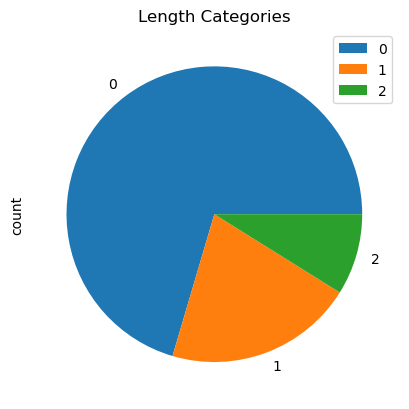

In [139]:
categories_counts.plot.pie(x=categories_counts.length_category, y='count')
plt.title('Length Categories')

10. Create a new column called gap that calculates the difference between the year a movie was added to Disney+ and its original release_year.
- Find the movie with the greatest gap.


In [164]:
movie_ratings['gap'] = movie_ratings['date_added'].str[-4:].astype('int') - movie_ratings['release_year']



# date_added release_year

C:\Users\geish\AppData\Local\Temp\ipykernel_49812\1421907780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_ratings['gap'] = movie_ratings['date_added'].str[-4:].astype('int') - movie_ratings['release_year']


In [168]:
movie_ratings.sort_values('gap', ascending=F).head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,length_category,gap
0,s1,Movie,A Spark Story,"Jason Sterman, Leanne Dare","Apthon Corbin, Louis Gonzales",NaN,"September 24, 2021",2021,TV-PG,88,Documentary,Two Pixar filmmakers strive to bring their uni...,average,0
282,s283,Movie,LEGO Star Wars Holiday Special,Ken Cunningham,"Helen Sadler, Omar Miller, Jake Green, Kelly M...",United States,"November 17, 2020",2020,TV-Y7-FV,48,"Action-Adventure, Animation, Comedy","On the festive Life Day, Rey and BB-8 embark o...",average,0
962,s963,Movie,Marvel Studios: Expanding the Universe,NaN,NaN,NaN,"November 12, 2019",2019,TV-PG,13,"Documentary, Family",An exciting look into the future of Marvel Stu...,short,0
571,s572,Movie,Forky Asks a Question: What is Cheese?,Bob Peterson,"Tony Hale, Jeff Garlin, Bob Peterson",United States,"January 3, 2020",2020,TV-G,6,"Animation, Comedy, Family","Buttercup, annoyed with all of Forky’s questio...",short,0
302,s303,Movie,Once Upon a Snowman,"Dan Abraham, Trent Correy","Josh Gad, Idina Menzel, Kristen Bell, Jonathan...",United States,"October 23, 2020",2020,TV-PG,12,"Animation, Comedy, Coming of Age",This new short film follows Olaf’s first steps...,short,0


- Find the average gap across all movies.